In [ ]:
import zipfile
import os
# Unzip the file
with zipfile.ZipFile('archive (11).zip', 'r') as zip_ref:
    zip_ref.extractall('archive (11)')


without smote

In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.models import Model
import cv2
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics
from sklearn.metrics import classification_report
import joblib

📁 Using dataset from: /content/archive (11)/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset
🖼️ Loading images...
✅ Loaded 1097 images from 3 classes.


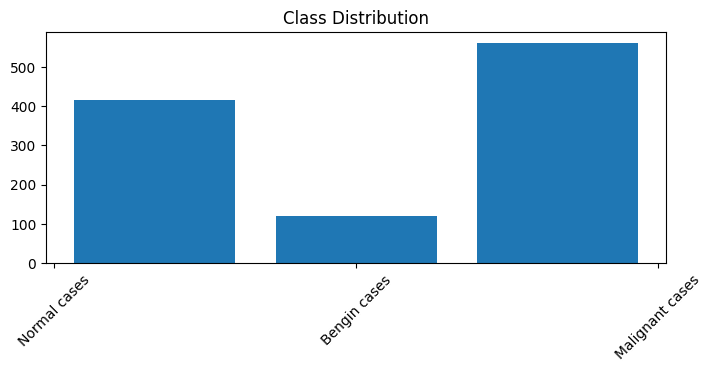

🔢 Encoded labels: ['Bengin cases' 'Malignant cases' 'Normal cases']
🔍 Extracting features using VGG16...
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
35/35 ━━━━━━━━━━━━━━━━━━━━ 659s 19s/step
✅ Extracted features shape: (1097, 512)
🔀 Splitting data using StratifiedShuffleSplit...
🧠 Building Neural Network classifier...
🏋️ Training the model...
Epoch 1/50


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 24ms/step - accuracy: 0.3687 - loss: 5.3913 - val_accuracy: 0.5625 - val_loss: 1.5200
Epoch 2/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4396 - loss: 3.5052 - val_accuracy: 0.7045 - val_loss: 1.1486
Epoch 3/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5530 - loss: 2.4910 - val_accuracy: 0.7955 - val_loss: 0.8748
Epoch 4/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5921 - loss: 2.0105 - val_accuracy: 0.8068 - val_loss: 0.7369
Epoch 5/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6360 - loss: 1.5751 - val_accuracy: 0.8125 - val_loss: 0.6602
Epoch 6/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6446 - loss: 1.5369 - val_accuracy: 0.8125 - val_loss: 0.6048
Epoch 7/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6767 - loss: 1.3069 - val_accuracy: 0.8295 - val_loss: 0.5511
Epoch 8/50
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7157 - loss: 1.1310 - val_accuracy: 0.8295 - val_loss: 0.4851


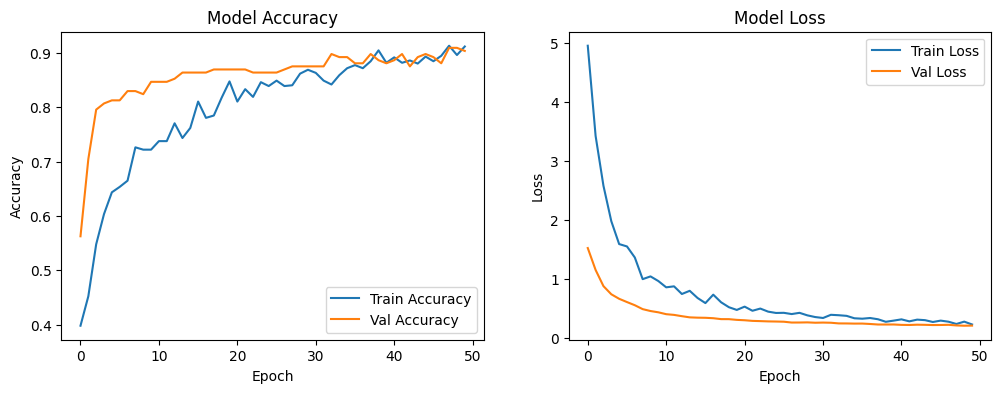

🧪 Testing on validation set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
🎯 Test Accuracy: 0.9000


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129534 (\N{RECEIPT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


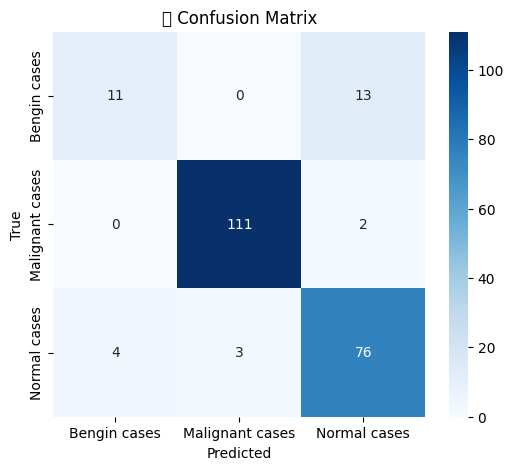


📊 Classification Report:

                 precision    recall  f1-score   support

   Bengin cases       0.73      0.46      0.56        24
Malignant cases       0.97      0.98      0.98       113
   Normal cases       0.84      0.92      0.87        83

       accuracy                           0.90       220
      macro avg       0.85      0.79      0.81       220
   weighted avg       0.90      0.90      0.89       220



In [ ]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications.vgg16 import preprocess_input
from tensorflow.keras.models import Model, Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam

# ✅ Step 1: Dataset path
data_dir = "/content/archive (11)/The IQ-OTHNCCD lung cancer dataset/The IQ-OTHNCCD lung cancer dataset"
print(f"📁 Using dataset from: {data_dir}")

# ✅ Step 2: Load and preprocess images
img_size = 224
images, labels = [], []

print("🖼️ Loading images...")
for class_name in os.listdir(data_dir):
    class_path = os.path.join(data_dir, class_name)
    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)
            img = cv2.imread(img_path)
            if img is not None:
                img = cv2.resize(img, (img_size, img_size))
                images.append(img)
                labels.append(class_name)

print(f"✅ Loaded {len(images)} images from {len(set(labels))} classes.")
plt.figure(figsize=(8, 3))
plt.hist(labels, bins=len(set(labels)), rwidth=0.8)
plt.title("Class Distribution")
plt.xticks(rotation=45)
plt.show()

images_np = np.array(images)
labels_np = np.array(labels)

# ✅ Step 3: Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels_np)
images_np = preprocess_input(images_np)
print(f"🔢 Encoded labels: {le.classes_}")

# ✅ Step 4: Feature extraction using VGG16
print("🔍 Extracting features using VGG16...")
base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
x = base_model.output
x = GlobalAveragePooling2D()(x)
model = Model(inputs=base_model.input, outputs=x)
features = model.predict(images_np)
print(f"✅ Extracted features shape: {features.shape}")

# ✅ Step 5: Stratified train-test split
print("🔀 Splitting data using StratifiedShuffleSplit...")
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(features, labels_encoded):
    X_train, X_test = features[train_idx], features[test_idx]
    y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

# ✅ Step 6: One-hot encode targets
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ✅ Step 7: Define the neural network
print("🧠 Building Neural Network classifier...")
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train_cat.shape[1], activation='softmax')
])
classifier.compile(optimizer=Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# ✅ Step 8: Train the classifier with early stopping
print("🏋️ Training the model...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = classifier.fit(X_train, y_train_cat,
                         validation_split=0.2,
                         epochs=50,
                         batch_size=32,
                         callbacks=[early_stop],
                         verbose=1)

# ✅ Step 9: Plot training vs validation accuracy/loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ✅ Step 10: Make predictions
print("🧪 Testing on validation set...")
y_pred = classifier.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ✅ Step 11: Accuracy
acc = accuracy_score(y_test, y_pred_classes)
print(f"🎯 Test Accuracy: {acc:.4f}")

# ✅ Step 12: Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues")
plt.title("🧾 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ✅ Step 13: Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))


with smote

🔀 Splitting data using StratifiedShuffleSplit...
📈 Applying SMOTE to balance training data...
✅ Class distribution after SMOTE: Counter({1: 448, 2: 448, 0: 448})


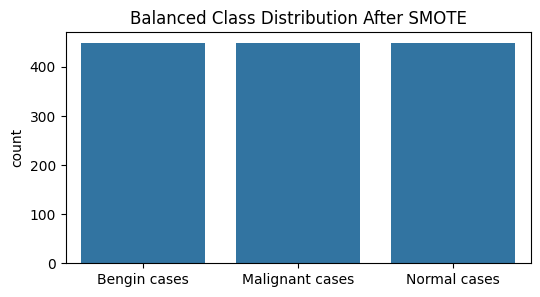

🧠 Building Neural Network classifier...
🏋️ Training the model...


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.3447 - loss: 5.2351 - val_accuracy: 0.4349 - val_loss: 1.2239
Epoch 2/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4206 - loss: 3.4458 - val_accuracy: 0.4870 - val_loss: 1.0063
Epoch 3/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5228 - loss: 2.1270 - val_accuracy: 0.5428 - val_loss: 0.8970
Epoch 4/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5588 - loss: 1.6933 - val_accuracy: 0.6357 - val_loss: 0.7473
Epoch 5/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6216 - loss: 1.1984 - val_accuracy: 0.6580 - val_loss: 0.7451
Epoch 6/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6255 - loss: 1.0996 - val_accuracy: 0.6543 - val_loss: 0.7014
Epoch 7/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6216 - loss: 1.0400 - val_accuracy: 0.6803 - val_loss: 0.6787
Epoch 8/50
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6705 - loss: 0.8965 - val_accuracy: 0.7138 - val_loss

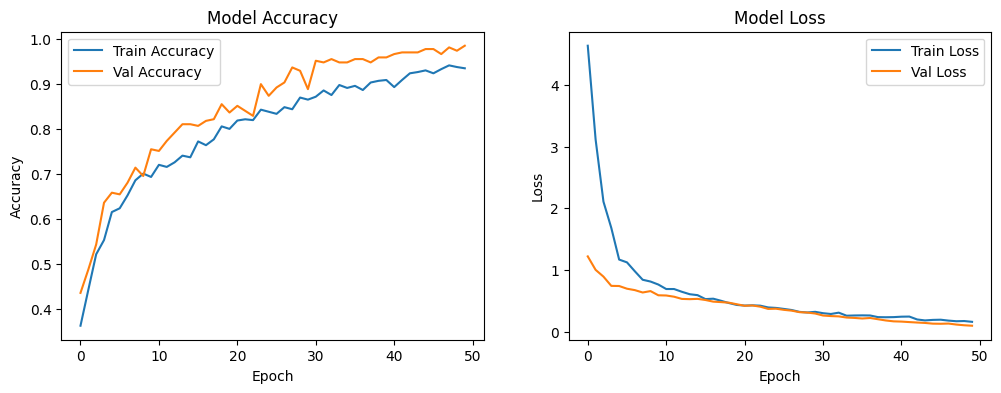

🧪 Testing on validation set...
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
🎯 Test Accuracy: 0.9545


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129534 (\N{RECEIPT}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


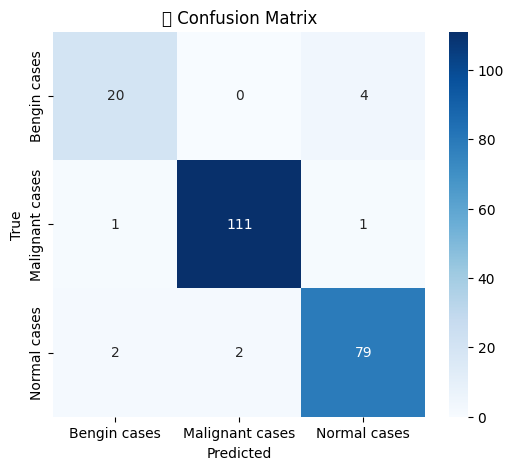


📊 Classification Report:

                 precision    recall  f1-score   support

   Bengin cases       0.87      0.83      0.85        24
Malignant cases       0.98      0.98      0.98       113
   Normal cases       0.94      0.95      0.95        83

       accuracy                           0.95       220
      macro avg       0.93      0.92      0.93       220
   weighted avg       0.95      0.95      0.95       220

💾 Saving the trained model...
✅ Model saved successfully.


In [ ]:

# ✅ Step 5: Stratified train-test split
print("🔀 Splitting data using StratifiedShuffleSplit...")
sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_idx, test_idx in sss.split(features, labels_encoded):
    X_train, X_test = features[train_idx], features[test_idx]
    y_train, y_test = labels_encoded[train_idx], labels_encoded[test_idx]

# ✅ Step 5.5: Apply SMOTE to balance classes in training data
print("📈 Applying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)

print("✅ Class distribution after SMOTE:", Counter(y_train))
plt.figure(figsize=(6,3))
sns.countplot(x=y_train)
plt.title("Balanced Class Distribution After SMOTE")
plt.xticks(ticks=np.arange(len(le.classes_)), labels=le.classes_)
plt.show()

# ✅ Step 6: One-hot encode targets
y_train_cat = to_categorical(y_train)
y_test_cat = to_categorical(y_test)

# ✅ Step 7: Define the neural network
print("🧠 Building Neural Network classifier...")
classifier = Sequential([
    Dense(256, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.5),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(y_train_cat.shape[1], activation='softmax')
])
classifier.compile(optimizer=Adam(learning_rate=1e-4),
                   loss='categorical_crossentropy',
                   metrics=['accuracy'])

# ✅ Step 8: Train the classifier with early stopping
print("🏋️ Training the model...")
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
history = classifier.fit(X_train, y_train_cat,
                         validation_split=0.2,
                         epochs=50,
                         batch_size=32,
                         callbacks=[early_stop],
                         verbose=1)

# ✅ Step 9: Plot training vs validation accuracy/loss
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label="Train Accuracy")
plt.plot(history.history['val_accuracy'], label="Val Accuracy")
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Val Loss")
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

# ✅ Step 10: Make predictions
print("🧪 Testing on validation set...")
y_pred = classifier.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# ✅ Step 11: Accuracy
acc = accuracy_score(y_test, y_pred_classes)
print(f"🎯 Test Accuracy: {acc:.4f}")

# ✅ Step 12: Confusion matrix
conf_mat = confusion_matrix(y_test, y_pred_classes)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_mat, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap="Blues")
plt.title("🧾 Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ✅ Step 13: Classification report
print("\n📊 Classification Report:\n")
print(classification_report(y_test, y_pred_classes, target_names=le.classes_))


# ✅ Step 14: Save the trained model
print("💾 Saving the trained model...")
classifier.save('path_to_save_model/my_model.h5')  # Replace with your desired file path
print("✅ Model saved successfully.")


#extra

In [ ]:
import os

# Define the path to your test images
test_data_dir = "/content/archive (11)/Test cases"

# List all files in the directory
test_images_list = os.listdir(test_data_dir)

# Print the number of files
print(f"Number of test images: {len(test_images_list)}")

# Optionally, print a few filenames to verify
print(f"First 5 images in the directory: {test_images_list[:5]}")  # Adjust if you want more


Number of test images: 197
First 5 images in the directory: ['000103_01_01_104.png', '000135_02_03_127.png', '004085_01_02_107.png', '000020_03_01_212.png', '000747_03_03_172.png']


In [ ]:
print(loaded_model.input_shape)


(None, 512)


In [ ]:
from tensorflow.keras.layers import Flatten

# Modify the feature model to include a Flatten layer
x = base_model.output
x = GlobalAveragePooling2D()(x)  # Output shape: (batch_size, 1, 512)
x = Flatten()(x)  # Flatten to shape (batch_size, 512)

feature_model = Model(inputs=base_model.input, outputs=x)

# Function to extract features from images
def extract_features(img_paths):
    features = []
    for img_path in img_paths:
        # Load the image and resize it
        img = image.load_img(img_path, target_size=(224, 224))
        img_array = image.img_to_array(img)
        img_array = np.expand_dims(img_array, axis=0)  # Add batch dimension
        img_array = preprocess_input(img_array)  # Preprocess the image

        # Extract features using the feature extraction model
        feature = feature_model.predict(img_array)
        features.append(feature)
    return np.array(features)

# Get paths for your test images
test_data_dir = "/content/archive (11)/Test cases"
test_images_list = os.listdir(test_data_dir)
test_image_paths = [os.path.join(test_data_dir, img_name) for img_name in test_images_list]

# Extract features for the test images
test_features = extract_features(test_image_paths)

# Check the shape of the features
print(f"Extracted feature shape: {test_features.shape}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 537ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 550ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 531ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 528ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 548ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 527ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 840ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 970ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 891ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 775ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 525ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 546ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 530ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 545ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 526ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
1

In [ ]:
# Flatten the features to shape (197, 512)
test_features = np.squeeze(test_features)

# Check the new shape of the features
print(f"Flattened feature shape: {test_features.shape}")

# Make predictions using the flattened features
predictions = loaded_model.predict(test_features)

# Output the predictions
print(f"Predictions for the test images: {predictions}")


Flattened feature shape: (197, 512)
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step  
Predictions for the test images: [[4.29243892e-02 1.79653079e-03 9.55278933e-01]
 [4.69052419e-03 1.98936963e-04 9.95110452e-01]
 [5.65452166e-02 4.08069638e-04 9.43046749e-01]
 [6.79711439e-03 3.35935061e-03 9.89843428e-01]
 [4.74069687e-03 3.37665260e-04 9.94921684e-01]
 [5.49633615e-02 1.24163842e-02 9.32620227e-01]
 [1.86879747e-03 1.23690770e-04 9.98007417e-01]
 [5.37673533e-01 1.20064686e-03 4.61125791e-01]
 [1.45498570e-03 5.79616346e-04 9.97965455e-01]
 [4.28063385e-02 5.31661093e-01 4.25532550e-01]
 [1.78610124e-02 8.95149933e-05 9.82049465e-01]
 [2.03805808e-02 4.69812512e-04 9.79149640e-01]
 [1.78619307e-02 5.96264494e-04 9.81541872e-01]
 [1.32126352e-02 2.12493842e-03 9.84662414e-01]
 [5.60508436e-03 1.88975959e-04 9.94206011e-01]
 [6.09513700e-01 4.73929802e-03 3.85747015e-01]
 [3.51959420e-03 3.14657722e-04 9.96165693e-01]
 [3.40284891e-02 2.93558202e-04 9.65677977e-01]
 [1.93521585e-02 6.06884540e